## Andre Marroquin

## Mauricio Lemus 

# Fase de implementacion y evaluacion del modelo

## Objetivo 

Implementar modelos de clasificacion sobre el dataset final recomendado por la fase previa, comparar lineas base, refinar los finalistas mas solidos y cerrar la evaluacion con metricas operativas, curva ROC, interpretacion y conclusiones.

## Division de datos y justificacion

Se trabajo con **parquetSeleccionado**, con un total de **5,120,000 registros**

- **Train total:** 4,160,000
- **Test total:** 960,000

### Entrenamiento

No se uso todo el train para entrenar

Se uso una **muestra estratificada de 180,000 registros**

Esta muestra se dividio asi:

- **Win32:** 135,000
- **Win64:** 45,000

La razon fue reducir costo computacional y mantener representatividad de clases y arquitecturas

### Validacion interna

Sobre esos **180,000 registros** se hizo una division adicional:

- **Train interno 75%:** 135,000
- **Validacion interna 25%:** 45,000

Esta division se uso para comparar configuraciones y ajustar el umbral sin tocar test

### Prueba final

La evaluacion final se hizo sobre todo el test, es decir:

- **960,000 registros**
- **18.75% del total del dataset**

La razon fue medir el rendimiento final sobre datos no vistos y sobre la particion completa de prueba

### Variables usadas

Para modelar se usaron:

- **60 caracteristicas**
- **1 variable objetivo:** label
- **1 variable auxiliar:** arquitectura

Ademas, **detection_ratio** fue excluida por riesgo de fuga de informacion

### Resumen

- **Dataset total:** 5,120,000
- **Train total:** 4,160,000
- **Test total:** 960,000
- **Train usado para modelar:** 180,000
- **Train interno:** 135,000
- **Validacion interna:** 45,000
- **Test usado para evaluacion final:** 960,000
- **Caracteristicas usadas:** 60


### Modelos utilizados y justificacion

#### Regresion Logistica
- Se utilizo como linea base. Su funcion fue servir como punto de comparacion inicial, ya que es un modelo simple, rapido y facil de interpretar. Permitio verificar si una solucion lineal era suficiente o si el problema necesitaba un enfoque mas complejo.

#### Extra Trees Base
- Se eligio porque era uno de los modelos mas coherentes con la fase anterior y porque suele rendir muy bien en datos tabulares. Su principal ventaja es que puede capturar relaciones no lineales e interacciones entre variables, algo importante en un problema de clasificacion de malware.

#### Hist Gradient BoostingBase
- Se uso como una alternativa avanzada para comparar otra familia de modelos basados en arboles. Su inclusion permitio evaluar si un enfoque de boosting podia competir o superar al ensamblado de arboles de ExtraTrees en este conjunto de datos.

### Refinamiento de modelos
Despues de la comparacion inicial, se refinaron las dos familias con mejor sentido para el problema: **ExtraTrees** y **HistGradientBoosting**. En esta etapa se probaron cambios en hiperparametros como el numero de arboles, la profundidad, la cantidad minima de muestras por hoja, la proporcion de variables por division, el numero de iteraciones, el learning_rate, el limite de hojas y la regularizacion.

Las configuraciones evaluadas fueron:

- ExtraTreesBaseAfinado
- ExtraTreesRefinado
- ExtraTreesProfundidadControlada
- HistGradientBoostingBaseAfinado
- HistGradientBoostingProfundo
- HistGradientBoostingHojaLimitada

## Utilizaciones de la fase pasada

- `artefactos/ember2024/parquetSeleccionado` como fuente principal de modelado.
- `artefactos/ember2024/exportaciones/caracteristicasRecomendadas.csv` para reutilizar las 60 variables sugeridas.
- `artefactos/ember2024/exportaciones/indiceDatasetSeleccionado.csv` para respetar la particion original `train` y `test`.
- `artefactos/ember2024/exportaciones/muestraModeladoCompacto.parquet` solo como referencia de control, no como base final, porque la muestra exploratoria esta concentrada en Win32 y no representa toda la mezcla de arquitecturas.
- La exclusion de `detection_ratio` ya definida en la fase anterior por riesgo de fuga de informacion.


In [1]:
# importacion de linbrerias necesarias
from pathlib import Path
import gc
import sys
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda valor: f"{valor:,.4f}")
sns.set_theme(style="whitegrid", context="talk")

# Configuracion y preparacion del flujo 

In [ ]:
# Centraliza rutas, semillas y utilidades de la fase
ProyectoRaiz = Path.cwd()
SemillaGlobal = 42
FilasMuestraEntrenamiento = 180_000
RutaIndiceSeleccionado = ProyectoRaiz / "artefactos/ember2024/exportaciones/indiceDatasetSeleccionado.csv"
RutaCaracteristicasRecomendadas = ProyectoRaiz / "artefactos/ember2024/exportaciones/caracteristicasRecomendadas.csv"
RutaRankingCaracteristicas = ProyectoRaiz / "artefactos/ember2024/exportaciones/rankingCaracteristicas.csv"
RutaMuestraModeladoCompacto = ProyectoRaiz / "artefactos/ember2024/exportaciones/muestraModeladoCompacto.parquet"
RutaParquetSeleccionado = ProyectoRaiz / "artefactos/ember2024/parquetSeleccionado"

MapaRutasProyecto = {
    "IndiceSeleccionado": RutaIndiceSeleccionado,
    "CaracteristicasRecomendadas": RutaCaracteristicasRecomendadas,
    "RankingCaracteristicas": RutaRankingCaracteristicas,
    "MuestraModeladoCompacto": RutaMuestraModeladoCompacto,
    "ParquetSeleccionado": RutaParquetSeleccionado,
}

# validacion de los archivos necesarios para la fase
def ValidarRutasNecesarias(MapaRutas):
    rutasFaltantes = [str(ruta) for ruta in MapaRutas.values() if not ruta.exists()]
    if rutasFaltantes:
        raise FileNotFoundError(f"No se encontraron las rutas esperadas: {rutasFaltantes}")

# carga de muestra estratificada por arquitectura con un numero objetivo de filas
def CargarMuestraEstratificada(TablaIndiceDf, ColumnasLectura, ParticionObjetivo, FilasObjetivo, Semilla):
    tablaParticion = TablaIndiceDf[TablaIndiceDf["particion"] == ParticionObjetivo].copy()
    totalesArquitectura = tablaParticion.groupby("arquitectura")["filasValidas"].sum().sort_values(ascending=False)
    asignaciones = (totalesArquitectura / totalesArquitectura.sum() * FilasObjetivo).round().astype(int)
    diferencia = FilasObjetivo - int(asignaciones.sum())
    if diferencia != 0:
        asignaciones.loc[totalesArquitectura.index[0]] += diferencia
    marcos = []
    for arquitectura, filasArquitectura in asignaciones.items():
        tablaArquitectura = (
            tablaParticion[tablaParticion["arquitectura"] == arquitectura]
            .sample(frac=1.0, random_state=Semilla)
            .reset_index(drop=True)
        )
        totalAcumulado = 0
        for _, fila in tablaArquitectura.iterrows():
            rutaChunk = ProyectoRaiz / fila["rutaParquetChunk"]
            chunkDf = pd.read_parquet(rutaChunk, columns=ColumnasLectura)
            filasRestantes = filasArquitectura - totalAcumulado
            if filasRestantes <= 0:
                break
            if len(chunkDf) > filasRestantes:
                chunkDf = chunkDf.sample(n=filasRestantes, random_state=Semilla)
            marcos.append(chunkDf)
            totalAcumulado += len(chunkDf)
            if totalAcumulado >= filasArquitectura:
                break
    return pd.concat(marcos, ignore_index=True)

# Para casos donde se desea cargar toda la partición sin muestreo
def CargarParticionCompleta(TablaIndiceDf, ColumnasLectura, ParticionObjetivo):
    tablaParticion = TablaIndiceDf[TablaIndiceDf["particion"] == ParticionObjetivo].copy().reset_index(drop=True)
    marcos = []
    for _, fila in tablaParticion.iterrows():
        rutaChunk = ProyectoRaiz / fila["rutaParquetChunk"]
        marcos.append(pd.read_parquet(rutaChunk, columns=ColumnasLectura))
    return pd.concat(marcos, ignore_index=True)

# se construyen los pipeles de procesamiento de los modelos base con sus hiperparametreos
def ConstruirModelosBase(Semilla):
    return {
        "RegresionLogistica": Pipeline(
            [
                ("Imputador", SimpleImputer(strategy="median")),
                ("Escalador", StandardScaler()),
                ("Modelo", LogisticRegression(max_iter=500, random_state=Semilla, class_weight="balanced")),
            ]
        ),
        "ExtraTreesBase": Pipeline(
            [
                ("Imputador", SimpleImputer(strategy="median")),
                (
                    "Modelo",
                    ExtraTreesClassifier(
                        n_estimators=240,
                        max_features="sqrt",
                        min_samples_leaf=1,
                        class_weight="balanced_subsample",
                        random_state=Semilla,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
        "HistGradientBoostingBase": Pipeline(
            [
                ("Imputador", SimpleImputer(strategy="median")),
                (
                    "Modelo",
                    HistGradientBoostingClassifier(
                        max_iter=220,
                        learning_rate=0.08,
                        max_depth=10,
                        min_samples_leaf=40,
                        random_state=Semilla,
                    ),
                ),
            ]
        ),
    }


### Interpretacion

Esta celda organiza la base de la fase de implementacion. Aqui se definieron las rutas principales del proyecto, la semilla de trabajo y las funciones necesarias para validar archivos, cargar los datos y construir los modelos base. Se deja preparado el flujo para trabajar de forma ordenada, reproducible y consistente con los artefactos generados en la fase anterior.

## Funciones de evaluacion y validacion del dataset

In [3]:
# se contruye modelo refinable segun su nomnre
def ConstruirModeloRefinable(NombreModelo, Configuracion, Semilla):
    if NombreModelo == "ExtraTrees":
        return ExtraTreesClassifier(random_state=Semilla, n_jobs=-1, **Configuracion)
    if NombreModelo == "HistGradientBoosting":
        return HistGradientBoostingClassifier(random_state=Semilla, **Configuracion)
    raise ValueError(f"Modelo no soportado para refinamiento: {NombreModelo}")

# se calcula las metricas principales para clasificacion binaria
def CalcularMetricasBinarias(yReal, yPred, yProb, NombreModelo, Umbral):
    return {
        "modelo": NombreModelo,
        "umbral": Umbral,
        "accuracy": accuracy_score(yReal, yPred),
        "precision": precision_score(yReal, yPred, zero_division=0),
        "recall": recall_score(yReal, yPred, zero_division=0),
        "f1": f1_score(yReal, yPred, zero_division=0),
        "aucRoc": roc_auc_score(yReal, yProb),
    }

# prepara un reporte de clasificacion en formato DataFrame
def PrepararReporteClasificacion(yReal, yPred):
    reporteDf = pd.DataFrame(classification_report(yReal, yPred, output_dict=True)).T
    mapaIndices = {
        "0": "Clase 0 Benigno",
        "1": "Clase 1 Malware",
        "accuracy": "Accuracy",
        "macro avg": "Macro avg",
        "weighted avg": "Weighted avg",
    }
    reporteDf.index = [mapaIndices.get(indice, indice) for indice in reporteDf.index]
    return reporteDf

# se prepara la matriz de confusion como una tabla
def PrepararMatrizConfusion(yReal, yPred):
    matriz = confusion_matrix(yReal, yPred)
    return pd.DataFrame(
        matriz,
        index=["Real 0 Benigno", "Real 1 Malware"],
        columns=["Pred 0 Benigno", "Pred 1 Malware"],
    )

# funcion prueba varios umbrales y ordena los resultados por desempeno
def BuscarMejorUmbral(yReal, yProb, ListaUmbrales):
    filas = []
    for umbral in ListaUmbrales:
        yPred = (yProb >= umbral).astype(int)
        filas.append(
            {
                "umbral": umbral,
                "accuracy": accuracy_score(yReal, yPred),
                "precision": precision_score(yReal, yPred, zero_division=0),
                "recall": recall_score(yReal, yPred, zero_division=0),
                "f1": f1_score(yReal, yPred, zero_division=0),
            }
        )
    return pd.DataFrame(filas).sort_values(["f1", "recall", "precision", "accuracy"], ascending=False).reset_index(drop=True)

# funcion que calcula metricas separadas por arquitectura
def PrepararMetricasPorArquitectura(ArquitecturaSr, yReal, yProb, Umbral):
    filas = []
    for arquitectura in sorted(ArquitecturaSr.unique()):
        mascara = ArquitecturaSr == arquitectura
        yRealArq = yReal.loc[mascara]
        yProbArq = yProb[mascara.to_numpy()]
        yPredArq = (yProbArq >= Umbral).astype(int)
        filas.append(
            {
                "arquitectura": arquitectura,
                "accuracy": accuracy_score(yRealArq, yPredArq),
                "precision": precision_score(yRealArq, yPredArq, zero_division=0),
                "recall": recall_score(yRealArq, yPredArq, zero_division=0),
                "f1": f1_score(yRealArq, yPredArq, zero_division=0),
                "aucRoc": roc_auc_score(yRealArq, yProbArq),
            }
        )
    return pd.DataFrame(filas)

# se validan las rutas necesarias para el proyecto
ValidarRutasNecesarias(MapaRutasProyecto)
TablaIndiceSeleccionadoDf = pd.read_csv(RutaIndiceSeleccionado)
CaracteristicasRecomendadasDf = pd.read_csv(RutaCaracteristicasRecomendadas)
RankingCaracteristicasDf = pd.read_csv(RutaRankingCaracteristicas)
ColumnasModelo = CaracteristicasRecomendadasDf["caracteristica"].tolist()
ColumnasLecturaModelado = ["label", "arquitectura"] + ColumnasModelo
PrimerRutaChunk = ProyectoRaiz / TablaIndiceSeleccionadoDf.iloc[0]["rutaParquetChunk"]

ResumenRutasDf = pd.DataFrame(
    {
        "recurso": list(MapaRutasProyecto.keys()),
        "ruta": [str(ruta) for ruta in MapaRutasProyecto.values()],
        "existe": [ruta.exists() for ruta in MapaRutasProyecto.values()],
    }
)
ResumenIndiceDf = (
    TablaIndiceSeleccionadoDf.groupby(["particion", "arquitectura"], as_index=False)["filasValidas"]
    .sum()
    .rename(columns={"filasValidas": "filas"})
)

print(f"Proyecto raiz: {ProyectoRaiz}")
print(f"Primer chunk detectado: {PrimerRutaChunk}")
print(f"Cantidad de caracteristicas recomendadas: {len(ColumnasModelo)}")
display(ResumenRutasDf)
display(ResumenIndiceDf)


Proyecto raiz: c:\Users\andre\OneDrive\Desktop\malware
Primer chunk detectado: c:\Users\andre\OneDrive\Desktop\malware\artefactos\ember2024\parquetSeleccionado\97902f7024e48d57\chunk_00000.parquet
Cantidad de caracteristicas recomendadas: 60


,recurso,ruta,existe
0,IndiceSeleccionado,c:\Users\andre\OneDrive\Desktop\malware\artefa...,True
1,CaracteristicasRecomendadas,c:\Users\andre\OneDrive\Desktop\malware\artefa...,True
2,RankingCaracteristicas,c:\Users\andre\OneDrive\Desktop\malware\artefa...,True
3,MuestraModeladoCompacto,c:\Users\andre\OneDrive\Desktop\malware\artefa...,True
4,ParquetSeleccionado,c:\Users\andre\OneDrive\Desktop\malware\artefa...,True


,particion,arquitectura,filas
0,test,Win32,720000
1,test,Win64,240000
2,train,Win32,3120000
3,train,Win64,1040000


### Interpretacion

Esta celda deja preparadas las funciones que se van a usar para evaluar y refinar los modelos, como el calculo de metricas, la matriz de confusion, el reporte de clasificacion, la busqueda de umbral y el analisis por arquitectura. Se validan las rutas principales del proyecto y se cargan los archivos base del modelado. El resultado confirma que el proyecto fue detectado correctamente, que el primer chunk del parquetSeleccionado esta disponible y que la fase de implementacion trabajara con las 60 caracteristicas recomendadas que se definieron en la fase anterior.



## Carga del dataset final de modelado

Se verifica el esquema real del parquetSeleccionado, se contrastan las columnas contra la lista recomendada y se deja documentado que la ruta principal para la fase de modelado es la version seleccionada por chunks.


In [4]:
# se carga un chunk de ejemplo para validar su esquema y contenido antes de cargar la muestra completa
PreviewChunkDf = pd.read_parquet(PrimerRutaChunk)
ColumnasMetaDetectadas = [columna for columna in PreviewChunkDf.columns if columna not in ColumnasModelo and columna != "label"]
ColumnasNoModelables = ["particion", "arquitectura", "archivoOrigen", "identificadorArchivo", "indiceChunk", "md5", "sha1", "sha256", "tlsh", "detection_ratio"]
ColumnasExcluidasModelado = [columna for columna in ColumnasMetaDetectadas if columna in ColumnasNoModelables]
CaracteristicasFaltantes = [columna for columna in ColumnasModelo if columna not in PreviewChunkDf.columns]

if "label" not in PreviewChunkDf.columns:
    raise ValueError("La variable objetivo label no existe en el dataset seleccionado.")
if CaracteristicasFaltantes:
    raise ValueError(f"Faltan caracteristicas recomendadas en el dataset seleccionado: {CaracteristicasFaltantes}")

# resume el esquema del chunk validado
ResumenEsquemaDf = pd.DataFrame(
    [
        {"metrica": "Filas en chunk ejemplo", "valor": int(len(PreviewChunkDf))},
        {"metrica": "Columnas en chunk ejemplo", "valor": int(PreviewChunkDf.shape[1])},
        {"metrica": "Columnas de modelado", "valor": int(len(ColumnasModelo))},
        {"metrica": "detection_ratio presente", "valor": "detection_ratio" in PreviewChunkDf.columns},
        {"metrica": "Variable objetivo", "valor": "label"},
    ]
)

# Este bloque resume la fuente elegida para la carga exploratoria
ResumenMuestraExploratoriaDf = pd.DataFrame(
    [
        {"metrica": "Muestra exploratoria existe", "valor": RutaMuestraModeladoCompacto.exists()},
        {"metrica": "Base final elegida", "valor": "parquetSeleccionado"},
    ]
)

# impresiones de resumenes y validaciones
print("Primeras columnas del chunk seleccionado")
display(pd.DataFrame({"columna": PreviewChunkDf.columns.tolist()[:20]}))
print("Columnas excluidas del modelado principal")
display(pd.DataFrame({"columna": ColumnasExcluidasModelado}))
print("Resumen del esquema validado")
display(ResumenEsquemaDf)
print("Resumen de la decision de carga")
display(ResumenMuestraExploratoriaDf)
display(PreviewChunkDf[["label", "particion", "arquitectura", "archivoOrigen", "identificadorArchivo"] + ColumnasModelo[:6]].head(5))


Primeras columnas del chunk seleccionado


,columna
0,label
1,particion
2,arquitectura
3,archivoOrigen
4,identificadorArchivo
5,indiceChunk
6,sectionEntropiaMax
7,headerCoffChar_dll
8,behaviorConteo
9,sectionOverlayEntropia


Columnas excluidas del modelado principal


,columna
0,particion
1,arquitectura
2,archivoOrigen
3,identificadorArchivo
4,indiceChunk


Resumen del esquema validado


,metrica,valor
0,Filas en chunk ejemplo,1500
1,Columnas en chunk ejemplo,66
2,Columnas de modelado,60
3,detection_ratio presente,False
4,Variable objetivo,label


Resumen de la decision de carga


,metrica,valor
0,Muestra exploratoria existe,True
1,Base final elegida,parquetSeleccionado


,label,particion,arquitectura,archivoOrigen,identificadorArchivo,sectionEntropiaMax,headerCoffChar_dll,behaviorConteo,sectionOverlayEntropia,authenticodeLatestSigningTime,sectionEntropiaStd
0,1,test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,97902f7024e48d57,4.3330,0,0,0.3003,0.0000,1.6217
1,1,test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,97902f7024e48d57,6.4902,0,1,6.2110,0.0000,2.0211
2,0,test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,97902f7024e48d57,3.8971,1,0,7.4938,"1,727,003,054.2990",0.9462
3,1,test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,97902f7024e48d57,6.7784,0,0,5.2065,0.0000,1.4216
4,1,test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,97902f7024e48d57,7.1729,0,1,4.9027,0.0000,1.4718


### Interpretacion

Esta celda se utilizo para revisar un chunk de ejemplo antes de cargar el conjunto de trabajo completo. Con ello se verifico que el dataset seleccionado realmente contiene la variable objetivo label, que las 60 caracteristicas recomendadas estan presentes y que no se estan arrastrando columnas no aptas para el modelado principal. Los resultados muestran que el chunk de prueba tiene 1500 filas y 66 columnas, de las cuales 60 corresponden a las variables de modelado. Tambien se confirma que detection_ratio no esta presente en esta version del dataset y que la fuente elegida para la fase de implementacion es correctamente parquetSeleccionado. 


## Preparacion del conjunto para entrenamiento y prueba

Se toma una muestra reproducible y proporcional por arquitectura desde train para iterar el entrenamiento sin romper el flujo por chunks. La evaluacion externa se mantiene sobre la particion test completa.


In [5]:
# mide el tiempo total de carga de los datos
InicioCarga = time.time()

# se carga una muestra estratificada de entrenamiento.
EntrenamientoMuestraDf = CargarMuestraEstratificada(
    TablaIndiceSeleccionadoDf,
    ColumnasLecturaModelado,
    ParticionObjetivo="train",
    FilasObjetivo=FilasMuestraEntrenamiento,
    Semilla=SemillaGlobal,
)

# carga la particion completa de prueba
PruebaCompletaDf = CargarParticionCompleta(
    TablaIndiceSeleccionadoDf,
    ColumnasLecturaModelado,
    ParticionObjetivo="test",
)
TiempoCargaSegundos = time.time() - InicioCarga

# se resume la distribucion por arquitectura y clase
DistribucionEntrenamientoDf = EntrenamientoMuestraDf.groupby(["arquitectura", "label"]).size().reset_index(name="conteo")
DistribucionPruebaDf = PruebaCompletaDf.groupby(["arquitectura", "label"]).size().reset_index(name="conteo")

# se separan variables predictoras, objetivo y arquitectura para train y test
XEntrenamientoDf = EntrenamientoMuestraDf[ColumnasModelo].astype(np.float32)
yEntrenamientoSr = EntrenamientoMuestraDf["label"].astype(np.int8)
ArquitecturaEntrenamientoSr = EntrenamientoMuestraDf["arquitectura"].copy()
XPruebaDf = PruebaCompletaDf[ColumnasModelo].astype(np.float32)
yPruebaSr = PruebaCompletaDf["label"].astype(np.int8)
ArquitecturaPruebaSr = PruebaCompletaDf["arquitectura"].copy()

# verifica los nulos y el tamano de los conjuntos
ResumenNulosDf = XEntrenamientoDf.isna().sum().sort_values(ascending=False).reset_index()
ResumenNulosDf.columns = ["caracteristica", "nulosTrain"]
ResumenConjuntosDf = pd.DataFrame(
    [
        {"conjunto": "Train muestra", "filas": int(len(XEntrenamientoDf)), "columnasModelo": int(XEntrenamientoDf.shape[1]), "ratioMalware": float(yEntrenamientoSr.mean())},
        {"conjunto": "Test completo", "filas": int(len(XPruebaDf)), "columnasModelo": int(XPruebaDf.shape[1]), "ratioMalware": float(yPruebaSr.mean())},
    ]
)

# imprime el resumen de carga, distribucion y nulos
print(f"Tiempo de carga total: {TiempoCargaSegundos:,.2f} segundos")
display(ResumenConjuntosDf)
print("Distribucion por arquitectura y clase en train")
display(DistribucionEntrenamientoDf)
print("Distribucion por arquitectura y clase en test")
display(DistribucionPruebaDf)
print("Caracteristicas con mas nulos en train")
display(ResumenNulosDf.head(15))
print(f"Tipos de dato en las variables de modelado: {sorted(set(map(str, XEntrenamientoDf.dtypes)))}")

#libera la memoria de los marcos originales ya que se han separado las variables necesarias para el modelado
DelEntrenamientoMuestraDf = EntrenamientoMuestraDf.shape
DelPruebaCompletaDf = PruebaCompletaDf.shape
del EntrenamientoMuestraDf
del PruebaCompletaDf
gc.collect()
print(f"Marcos originales liberados de memoria. Train previo: {DelEntrenamientoMuestraDf}, Test previo: {DelPruebaCompletaDf}")


Tiempo de carga total: 6.58 segundos


,conjunto,filas,columnasModelo,ratioMalware
0,Train muestra,180000,60,0.4917
1,Test completo,960000,60,0.5000


Distribucion por arquitectura y clase en train


,arquitectura,label,conteo
0,Win32,0,67269
1,Win32,1,67731
2,Win64,0,24233
3,Win64,1,20767


Distribucion por arquitectura y clase en test


,arquitectura,label,conteo
0,Win32,0,360000
1,Win32,1,360000
2,Win64,0,120000
3,Win64,1,120000


Caracteristicas con mas nulos en train


,caracteristica,nulosTrain
0,importsPromedioFuncionesPorDll,24287
1,sectionEntropiaMax,228
2,sectionEntropiaStd,228
3,sectionVsizeTotal,228
4,sectionEntropiaMedia,228
5,sectionTamanoTotal,228
6,sectionOverlayRatio,59
7,sectionOverlayTamano,59
8,headerDosELfanew,59
9,headerCoffNumeroSecciones,59


Tipos de dato en las variables de modelado: ['float32']
Marcos originales liberados de memoria. Train previo: (180000, 62), Test previo: (960000, 62)


### Interpretacion

En esta celda se cargaron los datos que se usaron en la fase de modelado. Para entrenamiento se tomo una muestra estratificada de 180,000 registros desde la particion train, mientras que para la evaluacion final se cargo la particion test completa con 960,000 registros. De esta manera, el entrenamiento se hizo sobre una muestra controlada, pero la prueba final se mantuvo sobre todo el conjunto externo disponible. Tambien se reviso la distribucion por arquitectura y clase, el numero de valores nulos y el tipo de dato de las variables de modelado. El resultado confirma que las caracteristicas quedaron en formato float32, lo que ayuda a reducir consumo de memoria, y que despues de separar las variables necesarias se pudieron liberar los marcos originales. En conjunto, esta celda deja listo el conjunto de entrenamiento y prueba para comenzar la comparacion de modelos.



## Implementacion de modelos base

Se entrenan tres referencias consistentes con el tipo de dataset disponible: una linea base lineal, un ensamblado de arboles alineado con la fase de seleccion y un gradiente histograma como alternativa tabular robusta.


In [6]:
# construye y entrena los modelos base
ModelosBase = ConstruirModelosBase(SemillaGlobal)
ResultadosBaseDetalle = {}

for nombreModelo, modelo in ModelosBase.items():
    inicioModelo = time.time()
    modelo.fit(XEntrenamientoDf, yEntrenamientoSr)
    tiempoAjuste = time.time() - inicioModelo
    probasPrueba = modelo.predict_proba(XPruebaDf)[:, 1]
    prediccionesPrueba = (probasPrueba >= 0.5).astype(np.int8)
    ResultadosBaseDetalle[nombreModelo] = {
        "ModeloEntrenado": modelo,
        "ProbabilidadesPrueba": probasPrueba,
        "PrediccionesPrueba": prediccionesPrueba,
        "Metricas": CalcularMetricasBinarias(yPruebaSr, prediccionesPrueba, probasPrueba, nombreModelo, 0.5),
        "TiempoAjusteSegundos": tiempoAjuste,
    }

# da tiempo de ajuste de cada modelo base
ResumenEntrenamientoBaseDf = pd.DataFrame(
    [{"modelo": nombreModelo, "tiempoAjusteSegundos": detalle["TiempoAjusteSegundos"]} for nombreModelo, detalle in ResultadosBaseDetalle.items()]
).sort_values("tiempoAjusteSegundos")

display(ResumenEntrenamientoBaseDf)


,modelo,tiempoAjusteSegundos
0,RegresionLogistica,1.5795
1,ExtraTreesBase,4.6407
2,HistGradientBoostingBase,5.9112


### Interpretacion

En esta celda se entrenaron los tres modelos base definidos para la comparacion inicial: **RegresionLogistica**, **ExtraTreesBase** y **HistGradientBoostingBase**. Ademas del entrenamiento, tambien se calcularon sus predicciones sobre el conjunto de prueba y se guardaron sus metricas para analizarlas mas adelante. Los tiempos de ajuste muestran que **RegresionLogistica** fue el modelo mas rapido, mientras que **ExtraTreesBase** y **HistGradientBoostingBase** requirieron un poco mas de tiempo. 



## Evaluacion inicial de modelos

La comparacion inicial usa el test externo completo. Ademas del resumen general, se muestra la matriz de confusion y el reporte de clasificacion del mejor modelo base para tener una referencia clara antes del refinamiento.


In [7]:
# Da tabla comparativa de metricas para los modelos base
TablaResultadosBaseDf = pd.DataFrame(
    [
        {
            "modelo": nombreModelo,
            "accuracy": detalle["Metricas"]["accuracy"],
            "precision": detalle["Metricas"]["precision"],
            "recall": detalle["Metricas"]["recall"],
            "f1": detalle["Metricas"]["f1"],
            "aucRoc": detalle["Metricas"]["aucRoc"],
            "tiempoAjusteSegundos": detalle["TiempoAjusteSegundos"],
        }
        for nombreModelo, detalle in ResultadosBaseDetalle.items()
    ]
).sort_values(["aucRoc", "f1", "accuracy"], ascending=False).reset_index(drop=True)

# Identifica el mejor modelo base y prepara sus reportes
NombreMejorBase = TablaResultadosBaseDf.loc[0, "modelo"]
PrediccionesMejorBase = ResultadosBaseDetalle[NombreMejorBase]["PrediccionesPrueba"]
MatrizConfusionBaseDf = PrepararMatrizConfusion(yPruebaSr, PrediccionesMejorBase)
ReporteClasificacionBaseDf = PrepararReporteClasificacion(yPruebaSr, PrediccionesMejorBase)

# imprime los resultados comparativos y reportes del mejor modelo base
print("Tabla comparativa inicial")
display(TablaResultadosBaseDf)
print(f"Matriz de confusion del mejor modelo base: {NombreMejorBase}")
display(MatrizConfusionBaseDf)
print(f"Reporte de clasificacion del mejor modelo base: {NombreMejorBase}")
display(ReporteClasificacionBaseDf)


Tabla comparativa inicial


,modelo,accuracy,precision,recall,f1,aucRoc,tiempoAjusteSegundos
0,ExtraTreesBase,0.9690,0.9772,0.9605,0.9688,0.9952,4.6407
1,HistGradientBoostingBase,0.9604,0.9636,0.9570,0.9603,0.9936,5.9112
2,RegresionLogistica,0.9129,0.9228,0.9012,0.9119,0.9754,1.5795


Matriz de confusion del mejor modelo base: ExtraTreesBase


,Pred 0 Benigno,Pred 1 Malware
Real 0 Benigno,469256,10744
Real 1 Malware,18972,461028


Reporte de clasificacion del mejor modelo base: ExtraTreesBase


,precision,recall,f1-score,support
Clase 0 Benigno,0.9611,0.9776,0.9693,"480,000.0000"
Clase 1 Malware,0.9772,0.9605,0.9688,"480,000.0000"
Accuracy,0.9690,0.9690,0.9690,0.9690
Macro avg,0.9692,0.9690,0.9690,"960,000.0000"
Weighted avg,0.9692,0.9690,0.9690,"960,000.0000"


### Interpretacion

Esta celda compara el rendimiento inicial de los modelos base entrenados. Los resultados muestran que **ExtraTreesBase** fue el mejor modelo en esta primera evaluacion, al alcanzar el mayor valor de AUC ROC, F1 y Accuracy frente a las otras alternativas. La matriz de confusion y el reporte de clasificacion confirman que su comportamiento es solido, con un desempeño equilibrado entre la clase benigna y la clase malware. Por esta razon, **ExtraTreesBase** se tomo como referencia principal para la siguiente etapa de ajuste y mejora.



## Refinamiento de modelos finalistas

Se refina sobre una division interna del train muestreado. El foco se pone en los dos finalistas mas consistentes de la evaluacion inicial, con una exploracion pequena pero realista de hiperparametros y con revision de umbral para el ganador


In [ ]:
# divide el entrenamiento en train interno y validacion interna
XTrainInternoDf, XValidacionInternaDf, yTrainInternoSr, yValidacionInternaSr = train_test_split(
    XEntrenamientoDf,
    yEntrenamientoSr,
    test_size=0.25,
    random_state=SemillaGlobal,
    stratify=yEntrenamientoSr,
)

# aplica imputacion de nulos para preparar los datos del refinamiento
ImputadorInterno = SimpleImputer(strategy="median")
XTrainInternoNp = ImputadorInterno.fit_transform(XTrainInternoDf)
XValidacionInternaNp = ImputadorInterno.transform(XValidacionInternaDf)

# define los experimentos de refinamiento para ambas familias de modelos
ExperimentosRefinamiento = [
    {"familiaModelo": "ExtraTrees", "nombreExperimento": "ExtraTreesBaseAfinado", "configuracion": {"n_estimators": 240, "max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt", "class_weight": "balanced_subsample"}},
    {"familiaModelo": "ExtraTrees", "nombreExperimento": "ExtraTreesRefinado", "configuracion": {"n_estimators": 420, "max_depth": None, "min_samples_leaf": 1, "max_features": 0.6, "class_weight": "balanced_subsample"}},
    {"familiaModelo": "ExtraTrees", "nombreExperimento": "ExtraTreesProfundidadControlada", "configuracion": {"n_estimators": 320, "max_depth": 22, "min_samples_leaf": 2, "max_features": 0.7, "class_weight": "balanced_subsample"}},
    {"familiaModelo": "HistGradientBoosting", "nombreExperimento": "HistGradientBoostingBaseAfinado", "configuracion": {"max_iter": 220, "learning_rate": 0.08, "max_depth": 10, "min_samples_leaf": 40, "l2_regularization": 0.0}},
    {"familiaModelo": "HistGradientBoosting", "nombreExperimento": "HistGradientBoostingProfundo", "configuracion": {"max_iter": 280, "learning_rate": 0.06, "max_depth": 12, "min_samples_leaf": 30, "l2_regularization": 0.1}},
    {"familiaModelo": "HistGradientBoosting", "nombreExperimento": "HistGradientBoostingHojaLimitada", "configuracion": {"max_iter": 320, "learning_rate": 0.05, "max_depth": None, "max_leaf_nodes": 31, "min_samples_leaf": 25, "l2_regularization": 0.0}},
]

# entrena y evalua cada experimento de refinamiento
ResultadosRefinamiento = []
DetallesRefinamiento = {}

for experimento in ExperimentosRefinamiento:
    inicioExperimento = time.time()
    modelo = ConstruirModeloRefinable(experimento["familiaModelo"], experimento["configuracion"], SemillaGlobal)
    modelo.fit(XTrainInternoNp, yTrainInternoSr)
    probasValidacion = modelo.predict_proba(XValidacionInternaNp)[:, 1]
    prediccionesValidacion = (probasValidacion >= 0.5).astype(np.int8)
    metricasExperimento = CalcularMetricasBinarias(yValidacionInternaSr, prediccionesValidacion, probasValidacion, experimento["nombreExperimento"], 0.5)
    metricasExperimento["familiaModelo"] = experimento["familiaModelo"]
    metricasExperimento["tiempoAjusteSegundos"] = time.time() - inicioExperimento
    metricasExperimento["configuracion"] = str(experimento["configuracion"])
    ResultadosRefinamiento.append(metricasExperimento)
    DetallesRefinamiento[experimento["nombreExperimento"]] = {
        "ModeloEntrenado": modelo,
        "ProbabilidadesValidacion": probasValidacion,
        "Configuracion": experimento["configuracion"],
        "FamiliaModelo": experimento["familiaModelo"],
    }

# selecciona el mejor experimento y busca el mejor umbral en validacion interna
TablaRefinamientoDf = pd.DataFrame(ResultadosRefinamiento).sort_values(["aucRoc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
NombreModeloRefinado = TablaRefinamientoDf.loc[0, "modelo"]
FamiliaModeloRefinado = TablaRefinamientoDf.loc[0, "familiaModelo"]
ConfiguracionGanadora = DetallesRefinamiento[NombreModeloRefinado]["Configuracion"]
TablaUmbralesDf = BuscarMejorUmbral(yValidacionInternaSr, DetallesRefinamiento[NombreModeloRefinado]["ProbabilidadesValidacion"], [0.35, 0.40, 0.45, 0.50, 0.55, 0.60])
UmbralGanador = float(TablaUmbralesDf.loc[0, "umbral"])

print("Resultados del refinamiento")
display(TablaRefinamientoDf)
print(f"Modelo refinado ganador: {NombreModeloRefinado}")
print(f"Configuracion ganadora: {ConfiguracionGanadora}")
print("Revision de umbrales sobre validacion interna")
display(TablaUmbralesDf)


Resultados del refinamiento


,modelo,umbral,accuracy,precision,recall,f1,aucRoc,familiaModelo,tiempoAjusteSegundos,configuracion
0,ExtraTreesRefinado,0.5000,0.9756,0.9807,0.9694,0.9750,0.9967,ExtraTrees,15.9574,"{'n_estimators': 420, 'max_depth': None, 'min_..."
1,ExtraTreesBaseAfinado,0.5000,0.9744,0.9789,0.9689,0.9739,0.9965,ExtraTrees,3.0670,"{'n_estimators': 240, 'max_depth': None, 'min_..."
2,ExtraTreesProfundidadControlada,0.5000,0.9734,0.9785,0.9671,0.9727,0.9960,ExtraTrees,12.8977,"{'n_estimators': 320, 'max_depth': 22, 'min_sa..."
3,HistGradientBoostingBaseAfinado,0.5000,0.9695,0.9758,0.9617,0.9687,0.9955,HistGradientBoosting,3.3210,"{'max_iter': 220, 'learning_rate': 0.08, 'max_..."
4,HistGradientBoostingProfundo,0.5000,0.9696,0.9763,0.9615,0.9688,0.9955,HistGradientBoosting,7.5769,"{'max_iter': 280, 'learning_rate': 0.06, 'max_..."
5,HistGradientBoostingHojaLimitada,0.5000,0.9688,0.9755,0.9607,0.9680,0.9953,HistGradientBoosting,4.4945,"{'max_iter': 320, 'learning_rate': 0.05, 'max_..."


Modelo refinado ganador: ExtraTreesRefinado
Configuracion ganadora: {'n_estimators': 420, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.6, 'class_weight': 'balanced_subsample'}
Revision de umbrales sobre validacion interna


,umbral,accuracy,precision,recall,f1
0,0.4500,0.9756,0.9764,0.9739,0.9752
1,0.5000,0.9756,0.9807,0.9694,0.9750
2,0.4000,0.9746,0.9706,0.9780,0.9743
3,0.5500,0.9749,0.9843,0.9644,0.9742
4,0.6000,0.9736,0.9875,0.9585,0.9728
5,0.3500,0.9724,0.9629,0.9817,0.9722


### Interpretacion

En esta celda se realizo el refinamiento de los modelos finalistas. Primero se dividio la muestra de entrenamiento en un conjunto interno de ajuste y otro de validacion, y despues se probaron varias configuraciones tanto para **ExtraTrees** como para **HistGradientBoosting**.

Los resultados muestran que la mejor configuracion fue **ExtraTreesRefinado**, ya que alcanzo el mejor equilibrio entre AUC ROC, F1 y Accuracy en la validacion interna. Ademas, la revision de umbrales indico que **0.45** era la opcion mas conveniente para el cierre final, porque ofrecio el mejor balance entre precision y recall.



## Evaluacion final del modelo refinado

El modelo refinado ganador se ajusta con toda la muestra train preparada para esta fase y se evalua sobre el test completo. La comparacion final muestra el antes y despues frente al mejor modelo base.


In [9]:
# prepara los datos finales y entrena el modelo refinado ganador
ImputadorFinal = SimpleImputer(strategy="median")
XEntrenamientoFinalNp = ImputadorFinal.fit_transform(XEntrenamientoDf)
XPruebaFinalNp = ImputadorFinal.transform(XPruebaDf)
ModeloRefinadoFinal = ConstruirModeloRefinable(FamiliaModeloRefinado, ConfiguracionGanadora, SemillaGlobal)
InicioFinal = time.time()
ModeloRefinadoFinal.fit(XEntrenamientoFinalNp, yEntrenamientoSr)
TiempoAjusteFinalSegundos = time.time() - InicioFinal
ProbabilidadesFinales = ModeloRefinadoFinal.predict_proba(XPruebaFinalNp)[:, 1]
PrediccionesFinales = (ProbabilidadesFinales >= UmbralGanador).astype(np.int8)
MetricasFinalesDict = CalcularMetricasBinarias(yPruebaSr, PrediccionesFinales, ProbabilidadesFinales, NombreModeloRefinado, UmbralGanador)
MetricasFinalesDict["tiempoAjusteSegundos"] = TiempoAjusteFinalSegundos
MetricasFinalesDict["configuracion"] = str(ConfiguracionGanadora)

# prepara los reportes finales y la comparacion contra el mejor modelo base
MatrizConfusionFinalDf = PrepararMatrizConfusion(yPruebaSr, PrediccionesFinales)
ReporteClasificacionFinalDf = PrepararReporteClasificacion(yPruebaSr, PrediccionesFinales)
MetricasPorArquitecturaDf = PrepararMetricasPorArquitectura(ArquitecturaPruebaSr, yPruebaSr, ProbabilidadesFinales, UmbralGanador)
MejorBaseMetricas = ResultadosBaseDetalle[NombreMejorBase]["Metricas"]
TablaComparativaFinalDf = pd.DataFrame(
    [
        {"escenario": NombreMejorBase, "umbral": MejorBaseMetricas["umbral"], "accuracy": MejorBaseMetricas["accuracy"], "precision": MejorBaseMetricas["precision"], "recall": MejorBaseMetricas["recall"], "f1": MejorBaseMetricas["f1"], "aucRoc": MejorBaseMetricas["aucRoc"]},
        {"escenario": f"{NombreModeloRefinado} refinado", "umbral": MetricasFinalesDict["umbral"], "accuracy": MetricasFinalesDict["accuracy"], "precision": MetricasFinalesDict["precision"], "recall": MetricasFinalesDict["recall"], "f1": MetricasFinalesDict["f1"], "aucRoc": MetricasFinalesDict["aucRoc"]},
    ]
)
ResumenFinalDf = pd.DataFrame([MetricasFinalesDict])

# muestra la comparacion final y los reportes del modelo refinado
print("Comparacion mejor base vs modelo refinado")
display(TablaComparativaFinalDf)
print("Metricas finales del modelo refinado")
display(ResumenFinalDf)
print("Matriz de confusion final")
display(MatrizConfusionFinalDf)
print("Reporte de clasificacion final")
display(ReporteClasificacionFinalDf)
print("Metricas por arquitectura en test completo")
display(MetricasPorArquitecturaDf)


Comparacion mejor base vs modelo refinado


,escenario,umbral,accuracy,precision,recall,f1,aucRoc
0,ExtraTreesBase,0.5000,0.9690,0.9772,0.9605,0.9688,0.9952
1,ExtraTreesRefinado refinado,0.4500,0.9709,0.9735,0.9682,0.9708,0.9949


Metricas finales del modelo refinado


,modelo,umbral,accuracy,precision,recall,f1,aucRoc,tiempoAjusteSegundos,configuracion
0,ExtraTreesRefinado,0.4500,0.9709,0.9735,0.9682,0.9708,0.9949,26.7252,"{'n_estimators': 420, 'max_depth': None, 'min_..."


Matriz de confusion final


,Pred 0 Benigno,Pred 1 Malware
Real 0 Benigno,467356,12644
Real 1 Malware,15270,464730


Reporte de clasificacion final


,precision,recall,f1-score,support
Clase 0 Benigno,0.9684,0.9737,0.9710,"480,000.0000"
Clase 1 Malware,0.9735,0.9682,0.9708,"480,000.0000"
Accuracy,0.9709,0.9709,0.9709,0.9709
Macro avg,0.9709,0.9709,0.9709,"960,000.0000"
Weighted avg,0.9709,0.9709,0.9709,"960,000.0000"


Metricas por arquitectura en test completo


,arquitectura,accuracy,precision,recall,f1,aucRoc
0,Win32,0.9721,0.9752,0.9690,0.9721,0.9955
1,Win64,0.9673,0.9686,0.9658,0.9672,0.9932


### Interpretacion

En esta celda se entreno nuevamente el mejor modelo refinado usando toda la muestra de entrenamiento disponible y luego se evaluo sobre el conjunto test completo. Los resultados confirman que **ExtraTreesRefinado** fue la mejor opcion final, con un rendimiento alto y bastante equilibrado entre precision, recall y F1. La comparacion con el mejor modelo base muestra que el refinamiento si aporto una mejora real, sobre todo en **recall** y **F1**, lo que es importante porque ayuda a recuperar mas casos de malware.


## Curvas ROC y visualizaciones de rendimiento

Se comparan las curvas ROC de los modelos base contra el refinado y se agrega la matriz de confusion final como apoyo visual para el analisis operativo.


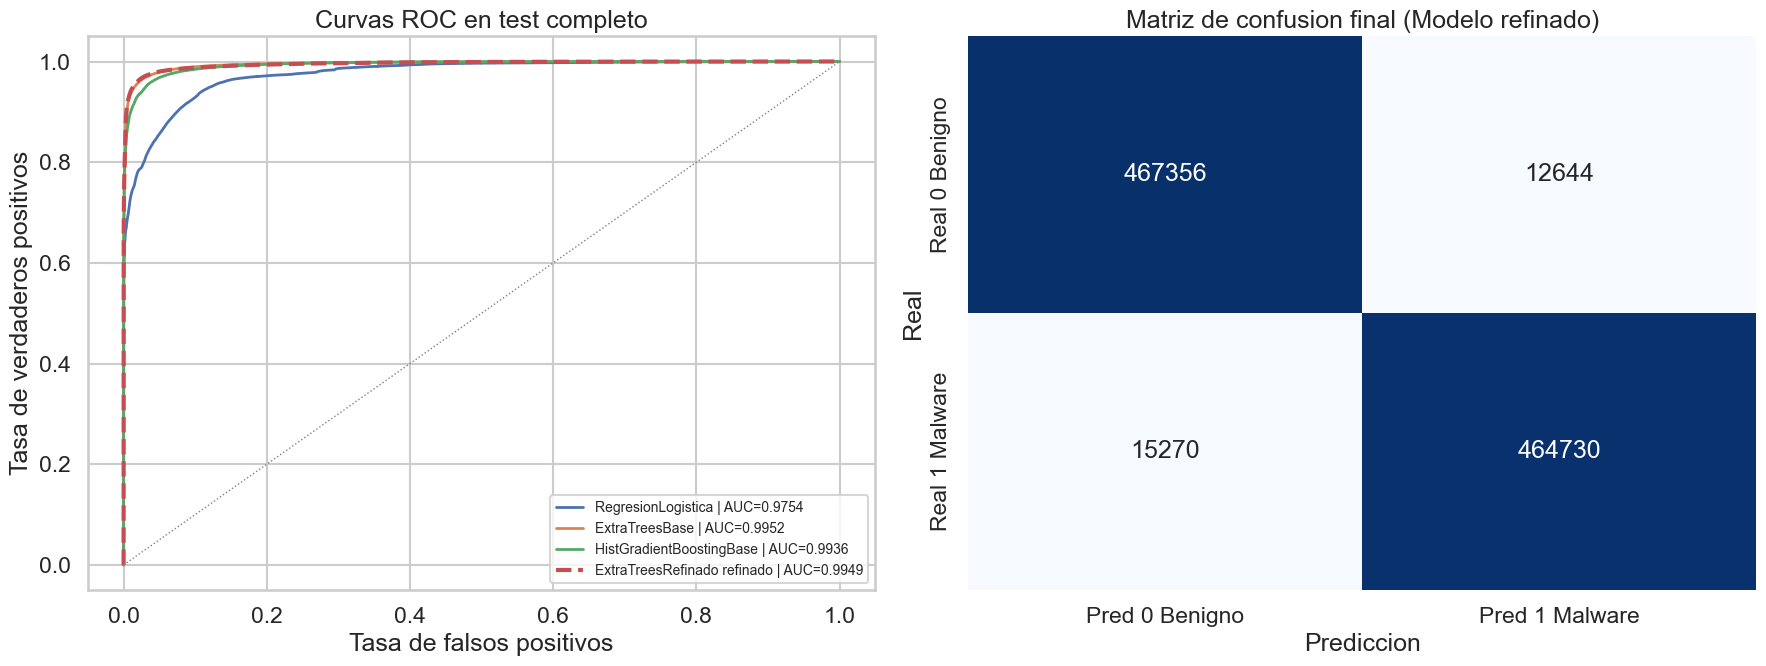

In [10]:
# grafica las curvas ROC de los modelos base y del modelo refinado final
plt.close("all")
figura, ejes = plt.subplots(1, 2, figsize=(18, 7))

for nombreModelo, detalle in ResultadosBaseDetalle.items():
    fpr, tpr, _ = roc_curve(yPruebaSr, detalle["ProbabilidadesPrueba"])
    etiqueta = f"{nombreModelo} | AUC={detalle['Metricas']['aucRoc']:.4f}"
    ejes[0].plot(fpr, tpr, linewidth=2, label=etiqueta)

fprFinal, tprFinal, _ = roc_curve(yPruebaSr, ProbabilidadesFinales)
ejes[0].plot(fprFinal, tprFinal, linewidth=3, linestyle="--", label=f"{NombreModeloRefinado} refinado | AUC={MetricasFinalesDict['aucRoc']:.4f}")
ejes[0].plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1)
ejes[0].set_title("Curvas ROC en test completo")
ejes[0].set_xlabel("Tasa de falsos positivos")
ejes[0].set_ylabel("Tasa de verdaderos positivos")
ejes[0].legend(loc="lower right", fontsize=10)

# grafica la matriz de confusion final del modelo refinado sobre test completo
sns.heatmap(MatrizConfusionFinalDf, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ejes[1])
ejes[1].set_title("Matriz de confusion final (Modelo refinado)")
ejes[1].set_xlabel("Prediccion")
ejes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()


## Interpretacion de Resultados y Conclusiones 

El mejor resultado de esta fase se obtuvo con el modelo **ExtraTreesRefinado**, utilizando la configuracion `{'n_estimators': 420, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.6, 'class_weight': 'balanced_subsample'}` y un umbral de decision de **0.45**. Al evaluarlo sobre el conjunto `test` completo, el modelo alcanzo un **Accuracy de 0.9709**, una **Precision de 0.9735**, un **Recall de 0.9682**, un **F1 score de 0.9708** y un **AUC ROC de 0.9949**. En terminos generales, estos resultados muestran un desempeño alto y bastante estable para el problema de clasificacion binaria entre archivos benignos y malware.

Si se observa el comportamiento por clase, el modelo mantiene un equilibrio adecuado. Para la clase **malware**, se obtuvo una **Precision de 0.9735**, un **Recall de 0.9682** y un **F1 score de 0.9708**, lo que indica que el modelo logra recuperar la mayor parte de los archivos maliciosos sin disparar una cantidad excesiva de falsos positivos. Para la clase **benigno**, los resultados fueron igualmente fuertes, con una **Precision de 0.9684**, un **Recall de 0.9737** y un **F1 score de 0.9710**. Esto sugiere que el clasificador no esta sesgado de forma marcada hacia una sola clase, sino que conserva un rendimiento bastante parejo en ambos sentidos.

Un punto importante es el analisis de errores. En el contexto de deteccion de malware, los errores mas delicados son los falsos negativos, porque representan archivos maliciosos que el modelo deja pasar como si fueran benignos. En la evaluacion final se registraron **15,270 falsos negativos** frente a **12,644 falsos positivos**. Aunque ambos tipos de error importan, los falsos negativos tienen un peso mayor desde la perspectiva de seguridad. Aun asi, la diferencia entre ambos no es desproporcionada y el comportamiento general del modelo sigue siendo consistente. El ajuste del umbral a **0.45** ayudo justamente a mejorar la capacidad de recuperacion de malware sin romper el balance global del clasificador.

Tambien es importante comparar el resultado final con el mejor modelo base para ver si el refinamiento realmente aporto algo. En este caso, el modelo refinado mejoro **+0.0021 en F1** y **+0.0077 en Recall**, aunque con una ligera disminucion de **-0.0037 en Precision**. Esto quiere decir que el refinamiento si tuvo efecto y que la mejora fue real, sobre todo en la capacidad de detectar archivos maliciosos. No es una diferencia enorme, pero si es suficiente para justificar la seleccion de la version refinada como cierre de esta fase.

Al separar los resultados por arquitectura, el modelo tambien se mantuvo fuerte. En **Win32** se obtuvo un **F1 score de 0.9721**, mientras que en **Win64** el valor fue de **0.9672**. La diferencia no es grande, por lo que se puede decir que el modelo generaliza bien en ambas arquitecturas. Sin embargo, el subconjunto de **Win64** sigue siendo un poco mas desafiante, ya que presenta un rendimiento ligeramente menor.

Desde la perspectiva practica, el modelo puede considerarse util como apoyo para la deteccion de malware. El nivel de separacion entre clases es alto y las metricas obtenidas indican que puede servir para tareas de filtrado, priorizacion o apoyo al analisis automatizado. De todas formas, no seria recomendable usarlo como unica capa de decision, ya que todavia existen errores restantes minimos, especialmente falsos negativos, que justifican mantenerlo dentro de un flujo mas amplio de evaluacion.

En conclusion, el modelo **ExtraTreesRefinado** fue el que mejor se adapto al conjunto de variables seleccionadas previamente y supero tanto a la linea base lineal como al gradiente histograma. La principal limitacion del proceso es que el entrenamiento no se realizo sobre la totalidad del conjunto train, sino sobre una muestra reproducible y balanceada por arquitectura de **180,000 registros**. Sin embargo, la prueba final si se hizo sobre todo el conjunto test, con **960,000 registros**, lo que da respaldo a las metricas reportadas. En conjunto, los resultados obtenidos son buenos y suficientes para considerar que el modelo cumple adecuadamente con su interpretacion.


## Alcance operativo de la salida probabilistica y consideraciones metodologicas (respondiendo objetivo y pregunta de investigacion)

#### Uso operativo de la salida probabilistica

- Mas alla de asignar una clase final, la salida probabilistica del modelo permite interpretar cada prediccion como un nivel de riesgo. Esto hace posible utilizar el modelo no solo para decidir si un archivo es benigno o malware, sino tambien para priorizar casos segun el grado de confianza con que fueron clasificados. En un contexto de seguridad, este enfoque es mas util que una salida estrictamente binaria, porque permite adaptar la respuesta al riesgo estimado y no tratar todos los casos sospechosos de la misma forma.

#### El umbral como herramienta de decision

- La seleccion de umbral incorporada en el cuaderno muestra que la decision final no depende unicamente del modelo, sino tambien del criterio con el que se transforma la probabilidad en accion. El umbral puede entenderse como una herramienta de control operativo, valores mas exigentes reducen alertas innecesarias, mientras que valores mas sensibles favorecen la deteccion de amenazas. Esto permite traducir el score del modelo en reglas practicas como permitir archivos con baja sospecha, enviar a revision manual archivos en una zona intermedia y bloquear o aislar aquellos con riesgo alto. El modelo se integra de mejor manera a un flujo de seguridad real, donde las decisiones deben balancear riesgo tecnico y capacidad operativa.

#### Balance entre reduccion de falsos negativos y costo operativo

- El trabajo realizado muestra que no basta con buscar buenas metricas, sino que tambien hay que cuidar el impacto operativo de las decisiones. En este caso, el ajuste del umbral sobre validacion interna ayuda justamente a mover ese balance de forma controlada. Dicho de manera simple, el modelo puede configurarse de forma mas sensible si se quiere reducir al maximo los falsos negativos, o de forma mas conservadora si se busca evitar demasiadas alertas o revisiones. Esto refuerza que la utilidad del modelo no depende solo de su rendimiento tecnico, sino tambien de que sus decisiones sean manejables en la practica.

#### Buenas practicas metodologicas identificadas

- Como parte del analisis, se identifican varias decisiones metodologicas. Entre ellas destacan la separacion clara entre entrenamiento, validacion interna y prueba final, la comparacion de varios modelos antes de elegir uno para refinamiento y la seleccion del umbral sin usar directamente el conjunto de test. Tambien fue usode buena practica el haber trabajado sobre el dataset ya seleccionado en la fase previa, mantener la evaluacion final sobre la particion externa completa y excluir detection_ratio del modelado principal para evitar fuga de informacion. 

#### Limitaciones metodologicas

- Tambien conviene dejar claro que el trabajo todavia tiene limites. El entrenamiento no se hizo sobre todo el conjunto train, sino sobre una muestra estratificada, lo cual vuelve la implementacion mas controlada y reproducible, pero no necesariamente representa el maximo rendimiento que podria lograrse con todos los datos. Ademas, aunque el cuaderno responde bien al escenario de clasificacion binaria evaluado, no entra todavia en escenarios mas exigentes como drift temporal, familias no vistas o conjuntos mas desafiantes. 

#### Mejoras futuras

- Como siguiente paso, lo mas natural seria mantener la misma base metodologica y ampliar su alcance. Algunas mejoras razonables serian reentrenar la mejor configuracion con una porcion mayor del conjunto de entrenamiento, definir reglas operativas mas explicitas a partir de rangos de probabilidad y probar el modelo en escenarios mas cercanos a condiciones reales de despliegue. En ese sentido, la implementacion actual puede verse como una base solida, ya demuestra valor predictivo, pero todavia puede crecer hacia una etapa mas orientada a decisiones de seguridad practicas y robustas.
